## Project objectives

- Segment mall customers into distinct groups based on Age, Annual Income, and Spending Score using K-Means clustering.
- Identify different types of shoppers to support targeted marketing and business decision-making.

In [42]:
import numpy as np
import pandas as pd

### Load the dataset, remove unneccesary columns, one-hot encoding for categorical column

In [43]:
# load the dataset
df = pd.read_csv("shopping_mall_customer_data.csv")

# drop unneccesary column
df = df.drop(['Customer ID'], axis = 1)

# one hot encoding of column 'Gender'
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

df.head()

,Age,Annual Income,Spending Score,Gender_Male
0,30,151479,89,True
1,58,185088,95,False
2,62,70912,76,False
3,23,55460,57,True
4,24,153752,76,True


### Dataset overview and EDA

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             15079 non-null  int64
 1   Annual Income   15079 non-null  int64
 2   Spending Score  15079 non-null  int64
 3   Gender_Male     15079 non-null  bool 
dtypes: bool(1), int64(3)
memory usage: 368.3 KB


#### Feature distribution

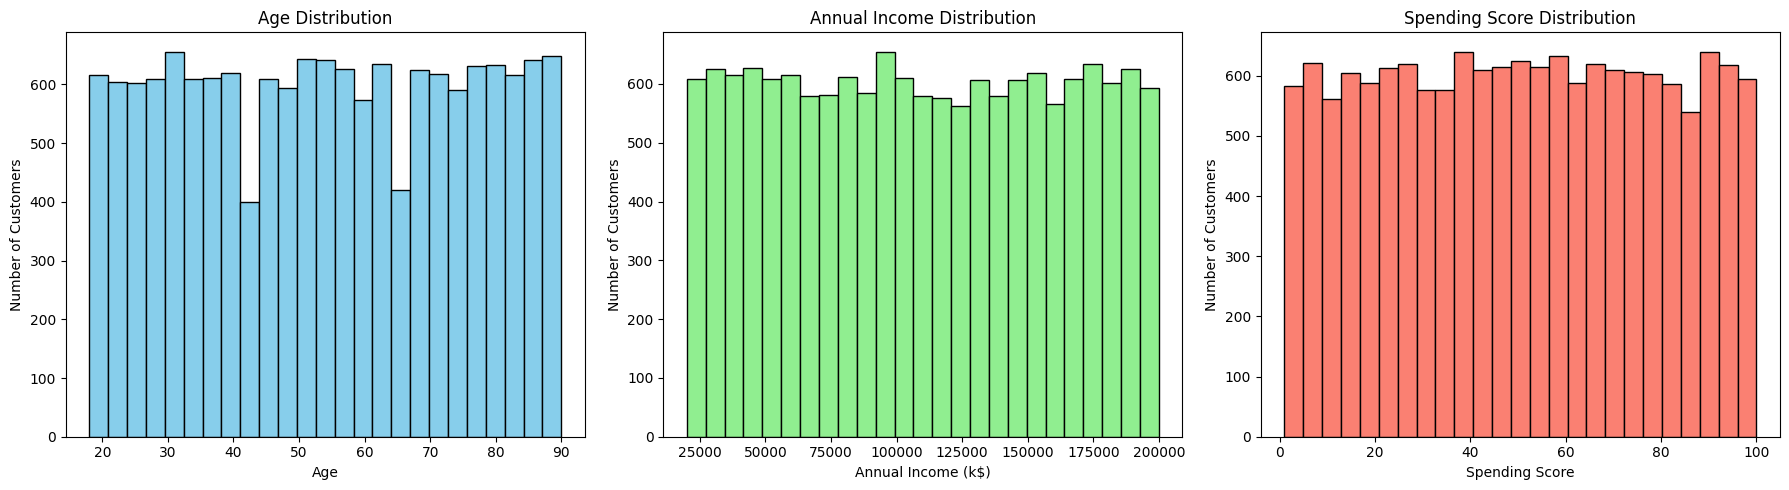

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Age
ax[0].hist(df['Age'], bins=25, color='skyblue', edgecolor='black')
ax[0].set_title('Age Distribution')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Number of Customers')

# Income
ax[1].hist(df['Annual Income'], bins=25, color='lightgreen', edgecolor='black')
ax[1].set_title('Annual Income Distribution')
ax[1].set_xlabel('Annual Income (k$)')
ax[1].set_ylabel('Number of Customers')

# Spending Score
ax[2].hist(df['Spending Score'], bins=25, color='salmon', edgecolor='black')
ax[2].set_title('Spending Score Distribution')
ax[2].set_xlabel('Spending Score')
ax[2].set_ylabel('Number of Customers')

plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\09_K-mean_clustering_mall_customer_segmentation\images\feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Insights

- **Age:** Customers are evenly distributed across age groups → no single dominant age segment.
- **Annual Income:** Income levels are uniformly spread → mall attracts both low-income and high-income customers.
- **Spending Score:** Spending behavior is also balanced → presence of low, medium, and high spenders in similar proportions.
- Overall, dataset has **no strong skewness or bias**, which is good for K-Means clustering.

#### Correlation heatmap

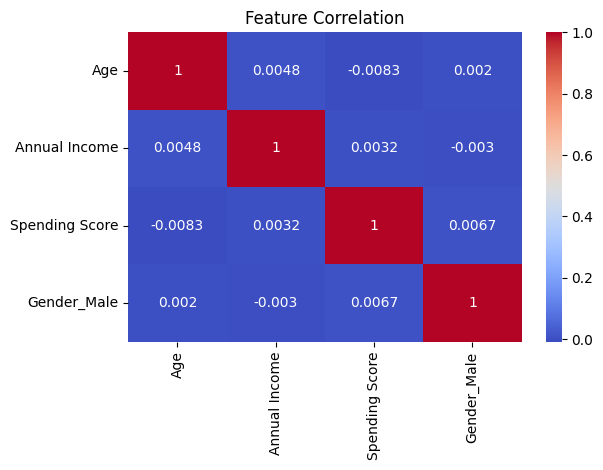

In [46]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\09_K-mean_clustering_mall_customer_segmentation\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Insights

- All feature correlations are **very close to 0** → variables are almost independent.
- **Age vs Spending Score:** No relationship → young and old customers spend similarly.
- **Income vs Spending Score:** No direct correlation → high income does not always mean high spending.
- **Gender vs other features:** Gender has negligible impact on income or spending.
- Dataset is ideal for K-Means, since clustering will rely on natural grouping rather than linear relationships.

#### Box plots

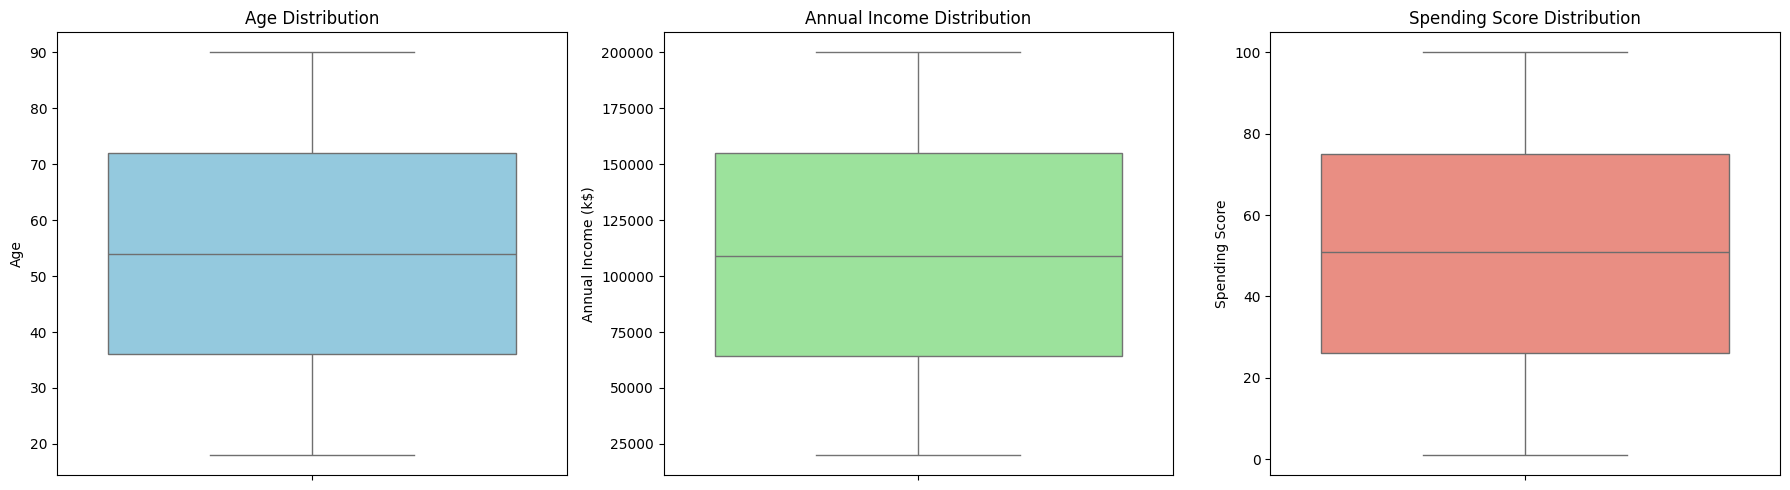

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Age
sns.boxplot(y=df['Age'], ax=ax[0], color='skyblue')
ax[0].set_title('Age Distribution')
ax[0].set_xlabel('')
ax[0].set_ylabel('Age')

# Annual Income
sns.boxplot(y=df['Annual Income'], ax=ax[1], color='lightgreen')
ax[1].set_title('Annual Income Distribution')
ax[1].set_xlabel('')
ax[1].set_ylabel('Annual Income (k$)')

# Spending Score
sns.boxplot(y=df['Spending Score'], ax=ax[2], color='salmon')
ax[2].set_title('Spending Score Distribution')
ax[2].set_xlabel('')
ax[2].set_ylabel('Spending Score')

plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\09_K-mean_clustering_mall_customer_segmentation\images\box_plots.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Insights

- **Age:** Wide spread of ages; no extreme outliers → balanced age representation.
- **Annual Income:** Large variation in income; no outliers present.
- **Spending Score:** Customers range from low to high spenders; no major outliers.
- Overall, dataset is clean and suitable for K-Means clustering.

### K-mean clustering model

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# select features
X = df[['Age','Annual Income','Spending Score']]

### Feature scaling

In [49]:
# feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow method to select n_clusters

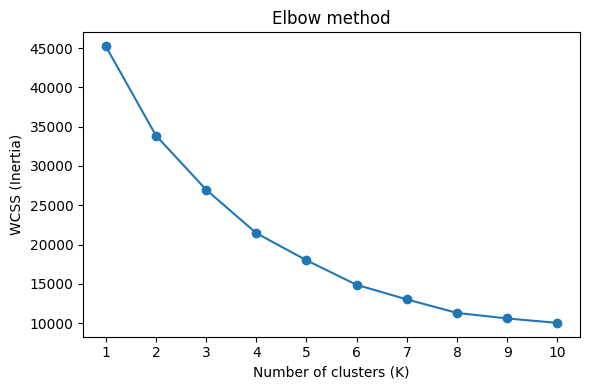

In [50]:
import matplotlib.pyplot as plt

# calculate WCSS for different K
wcss = []

# model
for k in range(1,11):
    kmeans = KMeans(
        n_clusters = k,
        init = 'k-means++',
        n_init = 10,
        random_state = 42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plot the elbow graph
plt.figure(figsize = (6,4))
plt.plot(range(1,11), wcss, marker = 'o')
plt.title('Elbow method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1,11))
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\09_K-mean_clustering_mall_customer_segmentation\images\ELBOW_method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

### Train the model

In [51]:
# train the model with K = 4

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

### Model evaluation

In [52]:
# model evaluation

from sklearn.metrics import silhouette_score

# inertia (WCSS)
print("WCSS (Inertia):", kmeans.inertia_)

# cluster labels
labels = kmeans.labels_

# silhouette score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

WCSS (Inertia): 21463.203945847537
Silhouette Score: 0.2641494943078979


### Cluster profile

In [53]:
df.groupby('Cluster').mean()

,Age,Annual Income,Spending Score,Gender_Male
Cluster,,,,
0,55.256329,66955.621044,23.262131,0.511603
1,34.366129,153901.835484,49.095968,0.492742
2,74.518414,150374.474891,52.998455,0.504249
3,51.690011,66367.607763,77.695711,0.505972


### Cluster plot

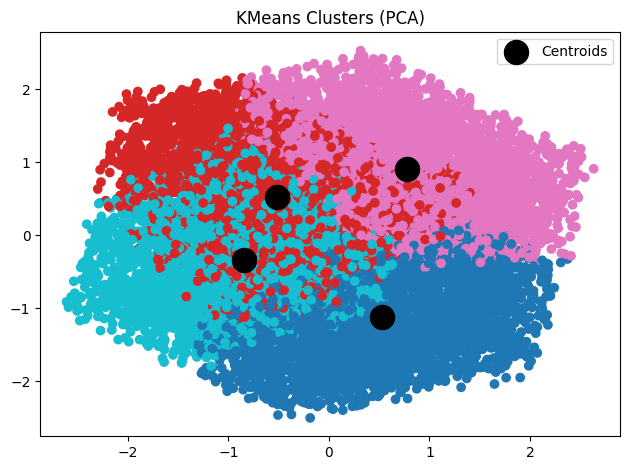

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            c='black', s=300, label='Centroids')

plt.legend()
plt.title("KMeans Clusters (PCA)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\09_K-mean_clustering_mall_customer_segmentation\images\cluster_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

### Key insights

- Customers can be grouped into **4 meaningful segments** based on purchasing behavior.
- **Income does not directly determine spending** — some high-income customers spend very little.
- A group of **low-income but high-spending customers** exists (impulsive buyers).
- **High-income & high-spending customers** represent premium/loyal customers and are most valuable to the business.
- **Low-income & low-spending customers** form budget shoppers with low engagement.
- Age has limited direct correlation with spending but helps refine segmentation.
- K-Means successfully identified natural behavioral patterns useful for **customer targeting, promotions, and retention strategies.**